# Graph Necking Expert (반단선(Necking) 전문가)

이 노트북은 **Necking Expert** 에이전트의 워크플로우를 테스트합니다.

In [1]:
# Necking Expert Graph Init
import sys
import os
from pathlib import Path
import json
import time

# 프로젝트 루트 경로 설정
current_dir = Path.cwd()
if "Agent_4_Necking Expert" in str(current_dir):
    project_root = current_dir.parent.parent
else:
    project_root = current_dir.parent if current_dir.name == "notebook" else current_dir
sys.path.insert(0, str(project_root))

# 환경 변수 로드
from dotenv import load_dotenv
load_dotenv(project_root / ".env")

print(f"✓ 현재 디렉토리: {current_dir}")
print(f"✓ 프로젝트 루트: {project_root}")

# 2. 테스트 이미지 준비
from src.utils import find_data_directory
from src.tools.experts.expert_utils import save_bytes_to_temp_file
from src.tools.experts.expert_utils import call_gemini_text, parse_json_response

# Necking Expert 관련 프롬프트

try:
    # 프로젝트 루트 기준으로 data 디렉토리 찾기
    data_dir_candidate = project_root / "data"
    if data_dir_candidate.exists():
        data_dir = str(data_dir_candidate)
        print(f"✓ Data 디렉토리 찾음: {data_dir}")
    else:
        # find_data_directory 함수 사용 (폴백)
        data_dir = find_data_directory()
    # 테스트할 이미지 파일명 (Partial Break 테스트에 적합한 이름 권장)
    test_image_name = "IMG_3994.jpg"
    test_image_path = Path(data_dir) / test_image_name
    
    if not test_image_path.exists():
        # 파일이 없으면 data 디렉토리의 첫 번째 이미지 사용
        image_files = list(Path(data_dir).glob("*.png")) + list(Path(data_dir).glob("*.jpg"))
        if image_files:
            test_image_path = image_files[0]
            print(f"⚠️ 지정된 이미지를 찾을 수 없어 {test_image_path.name}을 사용합니다.")
        else:
            raise FileNotFoundError("테스트할 이미지가 없습니다.")
            
    print(f"✓ 테스트 이미지: {test_image_path}")
    
    with open(test_image_path, 'rb') as f:
        image_data = f.read()
    temp_image_path = save_bytes_to_temp_file(image_data)
    print(f"✓ 임시 이미지 경로: {temp_image_path}")
    
except Exception as e:
    print(f"❌ 오류: {e}")
    import traceback
    traceback.print_exc()
    raise  # 에러를 다시 발생시켜 실행 중단

# temp_image_path가 정의되지 않았는지 확인
if 'temp_image_path' not in locals():
    raise RuntimeError("이미지 파일을 로드하지 못했습니다. temp_image_path가 정의되지 않았습니다.")

# 3. Hotspot 탐지 (메인 그래프와 동일한 방식)
from src.nodes.common_nodes import hotspot_detector_node
from src.state import InvestigationState

print("✓ Hotspot 탐지 중...")
# hotspot_detector_node는 InvestigationState를 받으므로 임시 State 생성
temp_investigation_state = InvestigationState(
    payload=[],
    image_path=temp_image_path,
    hotspots=None,
    expert_reports=[],
    expert_analysis_results={},
    expert_confidence_scores={},
    expert_evidence={},
    final_verdict=None,
    errors=[]
)
hotspot_result = hotspot_detector_node(temp_investigation_state)
detected_hotspots = hotspot_result.get("hotspots", [])
print(f"✓ 탐지된 Hotspots: {len(detected_hotspots)}개")

# 4. 그래프 빌드 및 상태 초기화 (실행 전 필수)
from src.graphs.necking_expert_graph import build_necking_expert_graph
from src.nodes.necking_nodes import NeckingExpertState

print("✓ 그래프 빌드 및 초기 상태 생성 중...")

initial_state = NeckingExpertState(
    messages=[],
    image_path=temp_image_path,
    hotspots=detected_hotspots,  # 탐지된 hotspots 사용
    hotspot_queue=None,
    preliminary_assessments=[],  # Map-Reduce Worker 결과 누적 (필수)
    analysis_results=[],
    
    # Loop 변수 초기화
    current_hotspot=None,
    detector_result=None,
    roi_image_path=None,
    
    # Classification & Specialist
    connection_type=None,
    is_wire=None,
    specialist_result=None,
    
    # Final Verdict
    verdict_report=None,
    verdict_confidence=None,
    verdict_result=None
)

graph = build_necking_expert_graph()
print("✓ 완료: initial_state 및 graph 객체 준비됨")

# 5. [노트북 전용] 출력 설정 (프로젝트 src/에는 영향 없음)
from datetime import datetime
import json
from src.utils import crop_roi_from_box

outputs_dir = project_root / "output/hotspots"
outputs_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
init_output_file = outputs_dir / f'Agent_4_Necking_Expert_Init_{timestamp}.md'

# 출력 내용 생성
output_content = f"""# Necking Expert 초기화 결과

## 실행 정보
- 실행 시간: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
- 프로젝트 루트: `{project_root}`
- 테스트 이미지: `{test_image_path}`
- 임시 이미지 경로: `{temp_image_path}`

## Hotspot 탐지 결과
- 탐지된 Hotspots 개수: {len(detected_hotspots)}개

### Hotspots 상세 정보
"""

# Hotspot 정보 추가 및 이미지 크롭
for idx, hotspot in enumerate(detected_hotspots, 1):
    hotspot_id = hotspot.get('id', 'N/A')
    severity = hotspot.get('severity_score', 0)
    feature = hotspot.get('suspected_feature', 'N/A')
    reason = hotspot.get('reason_for_selection', 'N/A')
    box = hotspot.get('box_2d', [])
    
    # box_2d 영역의 이미지 크롭 및 저장
    hotspot_image_path = None
    if box and len(box) == 4:
        try:
            # 이미지 파일명 생성: hotspot_{id}_{timestamp}.jpg
            hotspot_image_filename = f'hotspot_{hotspot_id}_{timestamp}.jpg'
            hotspot_image_path = outputs_dir / hotspot_image_filename
            
            # 이미지 크롭
            cropped_path = crop_roi_from_box(
                str(temp_image_path), 
                box, 
                output_path=str(hotspot_image_path),
                padding_ratio=0.1
            )
            hotspot_image_path = Path(cropped_path)
            print(f"  ✓ Hotspot {hotspot_id} 이미지 저장: {hotspot_image_path.name}")
        except Exception as e:
            print(f"  ⚠️ Hotspot {hotspot_id} 이미지 크롭 실패: {e}")
            hotspot_image_path = None
    
    # 마크다운 내용 생성 (이미지 경로 포함)
    image_markdown = ""
    if hotspot_image_path and hotspot_image_path.exists():
        # crop_roi_from_box가 이미 outputs_dir에 저장했으므로 파일명만 사용
        image_markdown = "\\n![Hotspot {0} Image]({1})\\n".format(hotspot_id, hotspot_image_path.name)
    
    output_content += f"""
#### Hotspot {idx}: ID {hotspot_id}
- 심각도 점수 (severity_score): {severity}
- 의심 특징 (suspected_feature): {feature}
- 선정 이유 (reason_for_selection): {reason}
- 바운딩 박스 (box_2d): {box}
{image_markdown}
"""
    
# 전체 JSON 정보도 추가
json_content = json.dumps(detected_hotspots, indent=2, ensure_ascii=False)
output_content += f"""
## 전체 Hotspot 데이터 (JSON)
```json
{json_content}
```

## 초기 상태 요약
- 이미지 경로: `{temp_image_path}`
- Hotspot 큐: 초기화 대기 중 (None)
- 분석 결과: 빈 리스트 (아직 분석 전)
- 그래프 상태: 준비 완료
"""

# 파일 저장
with open(init_output_file, 'w', encoding='utf-8') as f:
    f.write(output_content)

print(f'\n📁 [Init Output Saved] {init_output_file}')
print(f'✅ 초기화 결과 저장 완료: {len(detected_hotspots)}개 Hotspot 탐지됨')

✓ 현재 디렉토리: c:\Users\loidn\Documents\Projects\P_04_Scope\notebook
✓ 프로젝트 루트: c:\Users\loidn\Documents\Projects\P_04_Scope
✓ Data 디렉토리 찾음: c:\Users\loidn\Documents\Projects\P_04_Scope\data
✓ 테스트 이미지: c:\Users\loidn\Documents\Projects\P_04_Scope\data\IMG_3994.jpg
✓ 임시 이미지 경로: C:\Users\loidn\AppData\Local\Temp\tmpwupn7_qx.jpg
✓ Hotspot 탐지 중...
📂 [Hotspot Detector] 이미지 경로 감지: C:\Users\loidn\AppData\Local\Temp\tmpwupn7_qx.jpg

📡 [Hotspot Detector] 다중 발화 지점 탐색 시작... (이미지: C:\Users\loidn\AppData\Local\Temp\tmpwupn7_qx.jpg)
✅ [Hotspot Detector] 발견된 Hotspots: 4개
   - ID 1: bead_formation (Score: 92)
   - ID 2: thermal_damage (Score: 75)
   - ID 3: bead_formation (Score: 95)
   - ID 4: oxidation (Score: 48)
✓ 탐지된 Hotspots: 4개
✓ 그래프 빌드 및 초기 상태 생성 중...
✓ 완료: initial_state 및 graph 객체 준비됨
  ✓ Hotspot 1 이미지 저장: hotspot_1_20260119_203054.jpg
  ✓ Hotspot 2 이미지 저장: hotspot_2_20260119_203054.jpg
  ✓ Hotspot 3 이미지 저장: hotspot_3_20260119_203054.jpg
  ✓ Hotspot 4 이미지 저장: hotspot_4_20260119_203054.jpg

📁 [Ini

c:\Users\loidn\Documents\Projects\P_04_Scope\venv\Lib\site-packages\torchvision\transforms\functional_tensor.py:5: UserWarning: The torchvision.transforms.functional_tensor module is deprecated in 0.15 and will be **removed in 0.17**. Please don't rely on it. You probably just need to use APIs in torchvision.transforms.functional or in torchvision.transforms.v2.functional.
  warnings.warn(


🔧 Configuring Async Parallel Execution
✓ ThreadPoolExecutor: max_workers=7
✓ Expected parallel workers: 5
Multi-Hotspot Loop 전체 실행 (Necking)
[20:30:55.528] 🚀 Graph execution START

🚀 [Distribute Work] 3개 Worker에 병렬 분산 (Top-5)
   선택된 Hotspot IDs: [3, 1, 2]

🔄 [Worker #3] 증거 수집 시작...
✂️ [Worker #3] ROI 크롭... {'ymin': 457, 'xmin': 367, 'ymax': 798, 'xmax': 593}

🔄 [Worker #1] 증거 수집 시작...
✂️ [Worker #1] ROI 크롭... {'ymin': 213, 'xmin': 217, 'ymax': 382, 'xmax': 395}

🔄 [Worker #2] 증거 수집 시작...
✂️ [Worker #2] ROI 크롭... {'ymin': 315, 'xmin': 395, 'ymax': 545, 'xmax': 498}
✨ [Worker #1] ROI 이미지 2배 향상 적용 중...
✨ [Worker #2] ROI 이미지 2배 향상 적용 중...
✨ [Worker #3] ROI 이미지 2배 향상 적용 중...
✨ [Worker #2] 향상 완료: C:\Users\loidn\AppData\Local\Temp\roi_crop_u1uoa149.jpg
🔍 [Worker #2] 부품 유형 식별... (시도 1/5)
⚠️ [Worker #2] Classifier Retry 1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'The model is overloaded. Please try again later.', 'status': 'UNAVAILABLE'}}. (6.53s 대기)
✨ [Worker #1] 향상 완료: C:\Users\

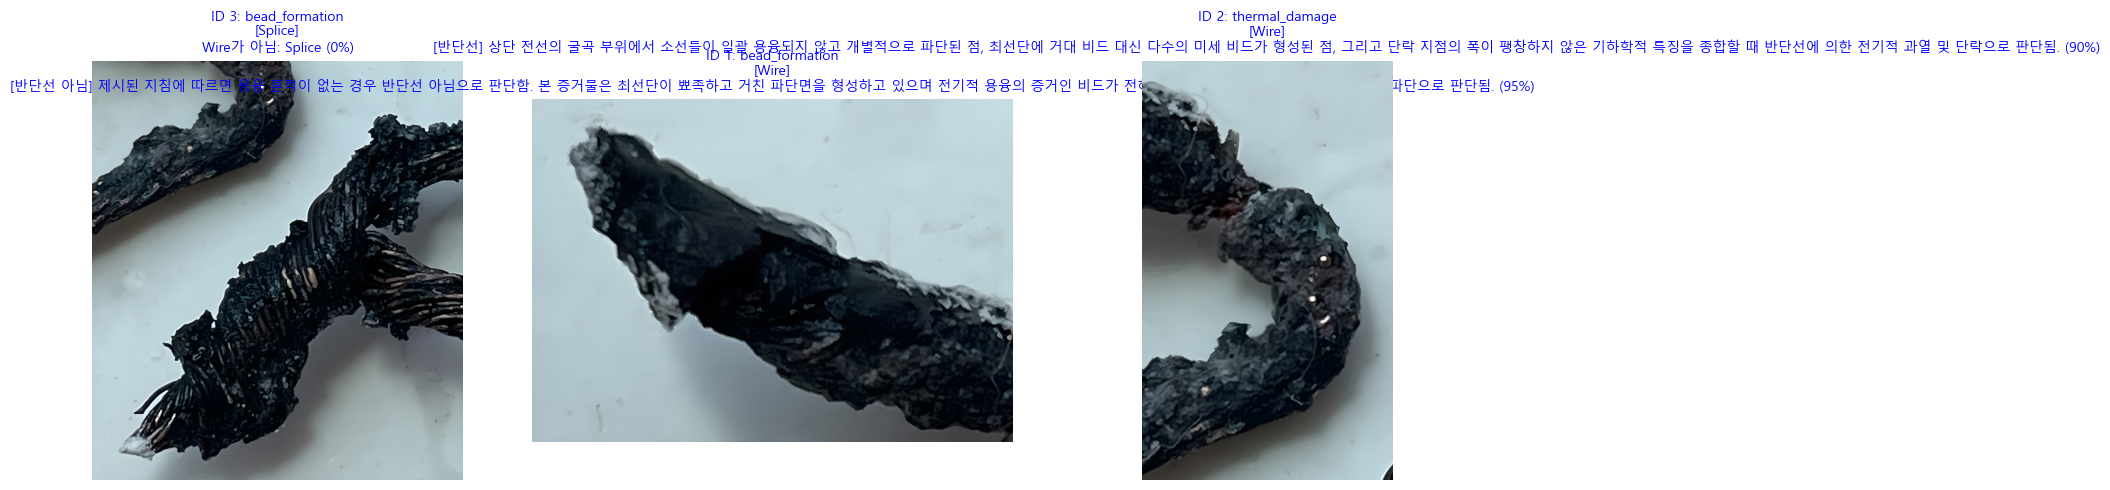

In [2]:
# Necking Expert Graph Run - With Parallel Execution Fix
# Copy this entire cell and replace Cell 2 in your notebook
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
# 🔥 PARALLEL EXECUTION FIX - Must be FIRST
import concurrent.futures
import asyncio
import time
from datetime import datetime
from config import TOP_N_HOTSPOTS
print("="*60)
print("🔧 Configuring Async Parallel Execution")
print("="*60)
# Configure ThreadPoolExecutor for true parallel execution
try:
    loop = asyncio.get_event_loop()
except RuntimeError:
    loop = asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
max_workers = TOP_N_HOTSPOTS + 2  # +2 for overhead
executor = concurrent.futures.ThreadPoolExecutor(
    max_workers=max_workers,
    thread_name_prefix="GeminiWorker"
)
loop.set_default_executor(executor)
print(f"✓ ThreadPoolExecutor: max_workers={max_workers}")
print(f"✓ Expected parallel workers: {TOP_N_HOTSPOTS}")
# Timestamp logging helper
def log_ts(msg):
    ts = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    print(f"[{ts}] {msg}")
print("="*60)
print("Multi-Hotspot Loop 전체 실행 (Necking)")
print("="*60)
start_time = time.time()
log_ts("🚀 Graph execution START")
try:
    # Recursion Limit을 넉넉히 주어야 Loop가 돕니다.
    final_state = await graph.ainvoke(initial_state, config={"recursion_limit": 50})
    elapsed = time.time() - start_time
    
    log_ts(f"✅ Graph execution END")
    print(f"\n✓ 전체 실행 완료 (소요시간: {elapsed:.2f}초)")
    
    # Performance check
    expected_seq = TOP_N_HOTSPOTS * 20  # 20s per worker sequentially
    print("\n" + "="*60)
    print("Performance Analysis")
    print("="*60)
    print(f"Expected (sequential): ~{expected_seq}s")
    print(f"Actual: {elapsed:.2f}s")
    if elapsed < expected_seq * 0.5:
        speedup = expected_seq / elapsed
        print(f"✅ PARALLEL CONFIRMED! Speedup: {speedup:.1f}x")
    else:
        print(f"⚠️ May still be sequential")
    print("="*60)
    
    # 분석된 결과들 가져오기
    analysis_results = final_state.get("analysis_results", [])
    # 최종 판정 보고서 저장
    import os
    from datetime import datetime
    
    verdict_report = final_state.get("verdict_report", "")
    verdict_confidence = final_state.get("verdict_confidence", 0)
    
    if verdict_report:
        # [노트북 전용] 출력 설정 (프로젝트 src/ 영향 없음)
        outputs_dir = project_root / "output"
        outputs_dir.mkdir(parents=True, exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        output_file = outputs_dir / f'Agent_4_Necking_Expert_{timestamp}.md'
        
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(verdict_report)
            f.write('\n\n---\n\n## 상세 분석 결과\n\n')
            
            for idx, res in enumerate(analysis_results, 1):
                h_info = res.get('hotspot_info', {})
                specialist = res.get('specialist_result', {})
                f.write(f'### Hotspot {idx}: ID {h_info.get("id")}\n')
                f.write(f'- Type: {res.get("connection_type", "N/A")}\n')
                f.write('```json\n')
                import json
                f.write(json.dumps({'hotspot_info': h_info, 'specialist_result': specialist}, indent=2, ensure_ascii=False))
                f.write('\n```\n\n')
        
        print(f'\n📁 [Output Saved] {output_file}')
        # .json 함께 저장 (동일 타임스탬프)
        import json
        json_path = output_file.with_suffix('.json')
        json_payload = {
            "verdict_report": verdict_report,
            "verdict_confidence": verdict_confidence,
            "verdict_result": final_state.get("verdict_result") or {},
            "analysis_results": [
                {"hotspot_id": r.get("hotspot_id"), "hotspot_info": r.get("hotspot_info", {}), "specialist_result": r.get("specialist_result", {}), "connection_type": r.get("connection_type", "N/A")}
                for r in analysis_results
            ],
        }
        with open(json_path, "w", encoding="utf-8") as jf:
            json.dump(json_payload, jf, indent=2, ensure_ascii=False, default=str)
        print(f'\n📁 [JSON Output Saved] {json_path}')
        print(f'✅ 최종 판정: 신뢰도 {verdict_confidence}%')
    else:
        print('⚠️ verdict_report가 비어있습니다!')
    # 한글 폰트 설정 (Windows)
    try:
        # Windows에서 사용 가능한 한글 폰트 찾기
        font_list = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Gulim', 'Batang']
        font_found = None
        for font_name in font_list:
            try:
                font_path = fm.findfont(fm.FontProperties(family=font_name))
                if font_path:
                    plt.rcParams['font.family'] = font_name
                    font_found = font_name
                    break
            except:
                continue
        
        if font_found:
            print(f"✓ 한글 폰트 설정: {font_found}")
        else:
            # 폰트를 찾지 못한 경우 경고만 출력하고 계속 진행
            print("⚠️ 한글 폰트를 찾을 수 없습니다. 한글이 제대로 표시되지 않을 수 있습니다.")
    except Exception as e:
        print(f"⚠️ 폰트 설정 중 오류: {e}")
    
    if not analysis_results:
        print("No analyzed images found.")
    else:
        num_images = len(analysis_results)
        if num_images > 0:
            # 서브플롯 크기 및 배열 설정
            cols = min(num_images, 5)
            rows = (num_images - 1) // cols + 1
            fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
            
            # axes가 단일 객체이거나 1차원 배열일 경우 처리
            if num_images == 1:
                axes = [axes]
            elif rows > 1:
                axes = axes.flatten()
            
            # 빈 서브플롯 숨기기
            if hasattr(axes, '__len__') and len(axes) > num_images:
                for ax in axes[num_images:]:
                    ax.axis('off')
            
            for idx, res in enumerate(analysis_results):
                # Data Extraction optimized for Deform Expert
                h_info = res.get('hotspot_info', {})
                hotspot_id = h_info.get('id', '?')
                feature = h_info.get('damage_type', 'Unknown')
                conn_type = res.get('connection_type', 'N/A')
                
                roi_path = res.get('roi_image_path')
                
                # Specialist Result Extraction
                # Deform Expert도 'specialist_result' 필드를 사용
                spec_res = res.get('specialist_result', {}) or {}
                
                verdict = spec_res.get('verdict', 'Indeterminate')
                # 긴 Verdict 문자열 줄임 처리
                if len(verdict) > 20: 
                    verdict = verdict.split('(')[0].strip() # 괄호 앞부분만 사용
                    
                conf = spec_res.get('confidence', 0)
                
                ax = axes[idx]
                
                if roi_path and os.path.exists(roi_path):
                    try:
                        img = Image.open(roi_path)
                        ax.imshow(img)
                        # Title 구성: ID, 판정 결과, 신뢰도
                        title_text = f"ID {hotspot_id}: {feature}\n[{conn_type}]\n{verdict} ({conf}%)"
                            
                        # Deform Expert 판정에 따른 색상
                        # 압착(Compression), 절단(Cut), 내부폭발(Internal) 등의 키워드에 따라 색상 구분
                        if "Compression" in verdict or "Crushing" in verdict or "Cut" in verdict or "Imprint" in verdict:
                             title_color = 'red' # 명확한 기계적 변형
                        elif "Internal" in verdict or "Explosion" in verdict:
                             title_color = 'purple' # 내부 요인
                        elif "Thermal" in verdict or "Melt" in verdict:
                             title_color = 'orange' # 열변형
                        else:
                             title_color = 'blue'
                        ax.set_title(title_text, fontsize=10, color=title_color)
                    except Exception as e:
                        ax.text(0.5, 0.5, "Error Loading", ha='center')
                        print(f"Error loading image {roi_path}: {e}")
                else:
                    ax.text(0.5, 0.5, "Image Not Found", ha='center')
                    ax.set_title(f"ID {hotspot_id}")
                    
                ax.axis('off')
            
            plt.tight_layout()
            plt.show()
except Exception as e:
    print(f"❌ 실행 중 오류: {e}")
    import traceback
    traceback.print_exc()
finally:
    # Cleanup executor
    executor.shutdown(wait=False)